# Projeto G1 — Desmatamento e Preservação Ambiental no Brasil
**Autor:** Marcelo Barbosa de Oliveira Junior  
**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python  
**Tema 19 • 2015–2024**

## 1. Introdução ao problema
Investigar a evolução do desmatamento, comparar regiões, estados e biomas e explorar a relação com queimadas. O problema ambiental envolve biodiversidade, recursos hídricos e mudanças climáticas. Este estudo é didático: usa uma base **simulada**, não dados oficiais, e não estima efeitos causais.

## 2. Explicação da base
Fonte: CSV fornecido pelo professor, `simulacao_desmatamento_brasil.csv`. São 4.440 registros, 14 colunas originais, 120 meses, cinco regiões, 20 UFs e seis biomas. Cada linha é uma observação simulada; a combinação mês/UF/bioma não é uma chave única.

| Campos | Descrição |
|---|---|
| ano, mes, data | Referência temporal |
| regiao, uf, bioma | Categorias geográficas simuladas |
| area_desmatada_km2 | Área desmatada por registro (km²) |
| area_preservada_km2 | Área preservada por registro (km²) |
| focos_queimada | Contagem de focos |
| chuva_mm | Chuva (mm) |
| temperatura_media | Temperatura; unidade não explicitada no arquivo |
| emissoes_co2 | Emissões estimadas; unidade não informada |
| unidades_conservacao | Contagem por registro, sem identificadores únicos |
| nivel_risco | Baixo, Médio, Alto e Crítico |

A base contém combinações de UF/bioma não representativas da geografia real. Não corrigimos essas combinações arbitrariamente. Áreas preservadas e unidades de conservação podem ser estoques repetidos entre meses: suas somas não representam área única ou quantidade única de unidades. Rankings também dependem da quantidade de registros por grupo.

## 3. Leitura dos dados

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
ROOT = Path.cwd().resolve()
if not (ROOT / "dados").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from analise import carregar, indicadores, ranking, numero
raw = pd.read_csv(ROOT / "dados/simulacao_desmatamento_brasil.csv", encoding="utf-8-sig")
print("Dimensões originais:", raw.shape)
display(raw.head())

Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories


Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories


Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories


Dimensões originais: (4440, 14)


,ano,mes,data,regiao,uf,bioma,area_desmatada_km2,area_preservada_km2,focos_queimada,chuva_mm,temperatura_media,emissoes_co2,unidades_conservacao,nivel_risco
0,2015,1,2015-01-01,Norte,AM,Caatinga,75.46,43451.70,16,46.9,27.5,82964.84,35,Alto
1,2015,1,2015-01-01,Norte,PA,Cerrado,69.69,66513.34,10,66.7,27.2,31417.01,7,Médio
2,2015,1,2015-01-01,Norte,PA,Pampa,25.99,2580.54,18,23.2,26.3,51231.24,33,Médio
3,2015,1,2015-01-01,Norte,RO,Caatinga,147.33,78446.65,14,123.9,24.7,24510.33,27,Baixo
4,2015,1,2015-01-01,Norte,TO,Caatinga,165.34,51615.00,16,60.4,25.2,71148.30,19,Alto


## 4. Limpeza e preparação
Preservamos o CSV original. A preparação normaliza espaços, converte datas e números, remove duplicatas exatas e exclui linhas inválidas com contagem explícita. Não há imputação arbitrária. Datas são conferidas contra ano e mês e medidas não negativas são validadas.

In [2]:
df, qualidade = carregar()
display(pd.Series(qualidade, name="Contagem"))
display(df.dtypes.to_frame("Tipo"))
assert len(df) == 4440
assert qualidade["duplicadas_removidas"] == 0
assert qualidade["invalidas_removidas"] == 0
assert qualidade["ausentes_originais"] == 0
print("Base integralmente válida pelas regras documentadas.")

linhas_originais        4440
duplicadas_removidas       0
invalidas_removidas        0
linhas_validas          4440
ausentes_originais         0
Name: Contagem, dtype: int64

,Tipo
ano,int64
mes,int64
data,datetime64[ns]
regiao,string[python]
uf,string[python]
bioma,string[python]
area_desmatada_km2,float64
area_preservada_km2,float64
focos_queimada,int64
chuva_mm,float64


Base integralmente válida pelas regras documentadas.


## 5. Engenharia de atributos
São criados trimestre, período mensal e indicador de risco elevado (Alto ou Crítico). A variação percentual anual é calculada após agregação, comparando períodos completos da base.

In [3]:
display(df[["data", "trimestre", "periodo", "nivel_risco", "risco_elevado"]].head())
anual = df.groupby("ano")["area_desmatada_km2"].sum().to_frame()
anual["variacao_percentual"] = anual.area_desmatada_km2.pct_change(fill_method=None) * 100
display(anual)

,data,trimestre,periodo,nivel_risco,risco_elevado
0,2015-01-01,1,2015-01,Alto,True
1,2015-01-01,1,2015-01,Alto,True
2,2015-01-01,1,2015-01,Alto,True
3,2015-01-01,1,2015-01,Alto,True
4,2015-01-01,1,2015-01,Crítico,True


,area_desmatada_km2,variacao_percentual
ano,,
2015,30368.55,NaN
2016,31022.21,2.152424
2017,33964.49,9.484431
2018,31740.19,-6.548899
2019,30838.18,-2.841854
2020,31802.48,3.126968
2021,31249.17,-1.739833
2022,31103.42,-0.466412
2023,32208.70,3.553564


## 6. Análise exploratória
Verificamos distribuição, cobertura e contagem por grupo. Não presumimos representação uniforme de estados ou biomas.

,count,mean,min,25%,50%,75%,max,std
ano,4440.0,2019.5,2015.0,2017.0,2019.5,2022.0,2024.0,2.872605
mes,4440.0,6.5,1.0,3.75,6.5,9.25,12.0,3.452441
data,4440,2019-12-16 10:48:00,2015-01-01 00:00:00,2017-06-23 12:00:00,2019-12-16 12:00:00,2022-06-08 12:00:00,2024-12-01 00:00:00,NaN
area_desmatada_km2,4440.0,70.856678,0.11,33.4975,59.09,96.25,373.01,50.235318
area_preservada_km2,4440.0,40458.639304,1003.97,20564.8975,40441.88,60038.8175,79991.89,22675.178232
focos_queimada,4440.0,15.098423,4.0,12.0,15.0,18.0,31.0,3.862761
chuva_mm,4440.0,89.105158,3.9,51.5,79.2,116.4,406.8,51.498076
temperatura_media,4440.0,27.01741,16.1,25.0,27.0,29.1,37.3,2.994477
emissoes_co2,4440.0,45716.934392,1025.78,23482.9275,45881.845,67811.475,89959.36,25545.327317
unidades_conservacao,4440.0,19.907883,1.0,10.0,20.0,29.0,39.0,11.148502


,registros,estados
regiao,,
Centro-Oeste,600,4
Nordeste,960,5
Norte,600,4
Sudeste,1560,4
Sul,720,3


bioma
Amazônia          739
Caatinga          708
Cerrado           744
Mata Atlântica    775
Pampa             716
Pantanal          758
Name: registros, dtype: int64

Número máximo de registros na mesma combinação ano/mês/UF/bioma: 4


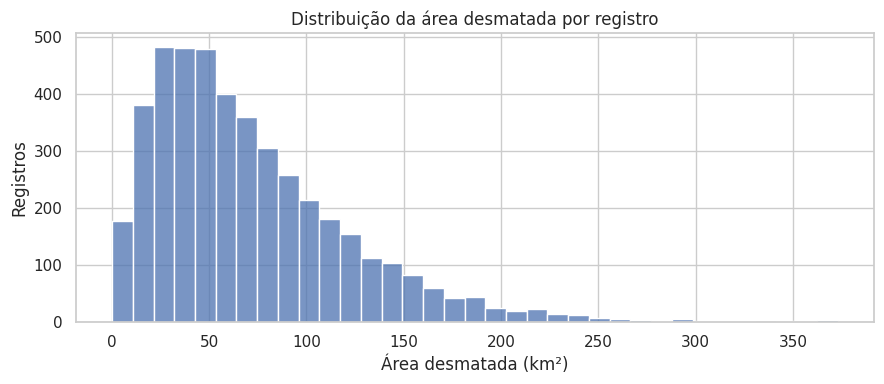

In [4]:
display(df.describe().T)
display(df.groupby("regiao").agg(registros=("uf","size"), estados=("uf","nunique")))
display(df.groupby("bioma").size().rename("registros"))
print("Número máximo de registros na mesma combinação ano/mês/UF/bioma:", df.groupby(["ano","mes","uf","bioma"]).size().max())
sns.set_theme(style="whitegrid", palette="deep")
fig, ax = plt.subplots(figsize=(9,4))
sns.histplot(data=df, x="area_desmatada_km2", bins=35, ax=ax)
ax.set(title="Distribuição da área desmatada por registro", xlabel="Área desmatada (km²)", ylabel="Registros")
plt.tight_layout(); plt.show()

## 7. KPIs
Área total desmatada, soma de área preservada registrada, bioma mais afetado, estado com maior soma desmatada, total de focos e emissões estimadas. A soma de preservação é exigida como indicador, mas não representa área territorial distinta. A unidade de emissão não foi fornecida.

In [5]:
k = indicadores(df)
display(pd.Series(k, name="Indicador"))
print("Área preservada média por registro (km²):", numero(df.area_preservada_km2.mean()))
print("Unidades de conservação médias por registro:", numero(df.unidades_conservacao.mean()))

desmatamento         314603.65
preservacao       179636358.51
queimadas                67037
co2                202983188.7
bioma           Mata Atlântica
estado                      RJ
Name: Indicador, dtype: object

Área preservada média por registro (km²): 40.458,64
Unidades de conservação médias por registro: 19,91


## 8. Gráficos
Matplotlib e Seaborn são utilizados nas figuras da análise; Plotly é utilizado nos gráficos interativos do dashboard. Figuras salvas em `imagens/` alimentam a página HTML.

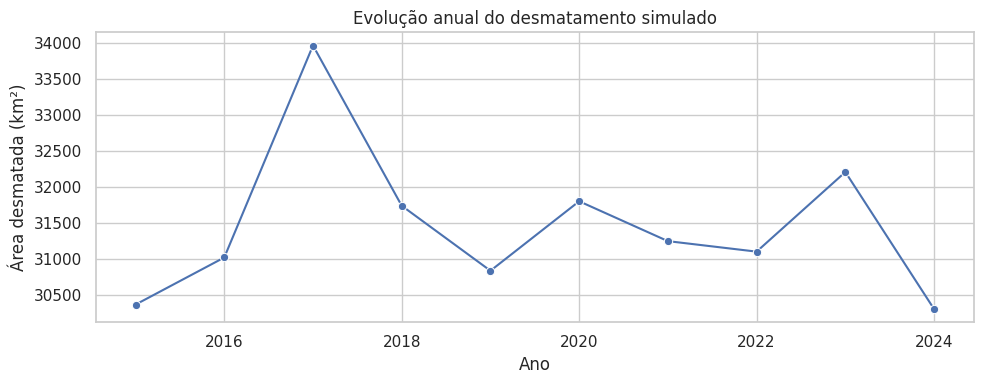

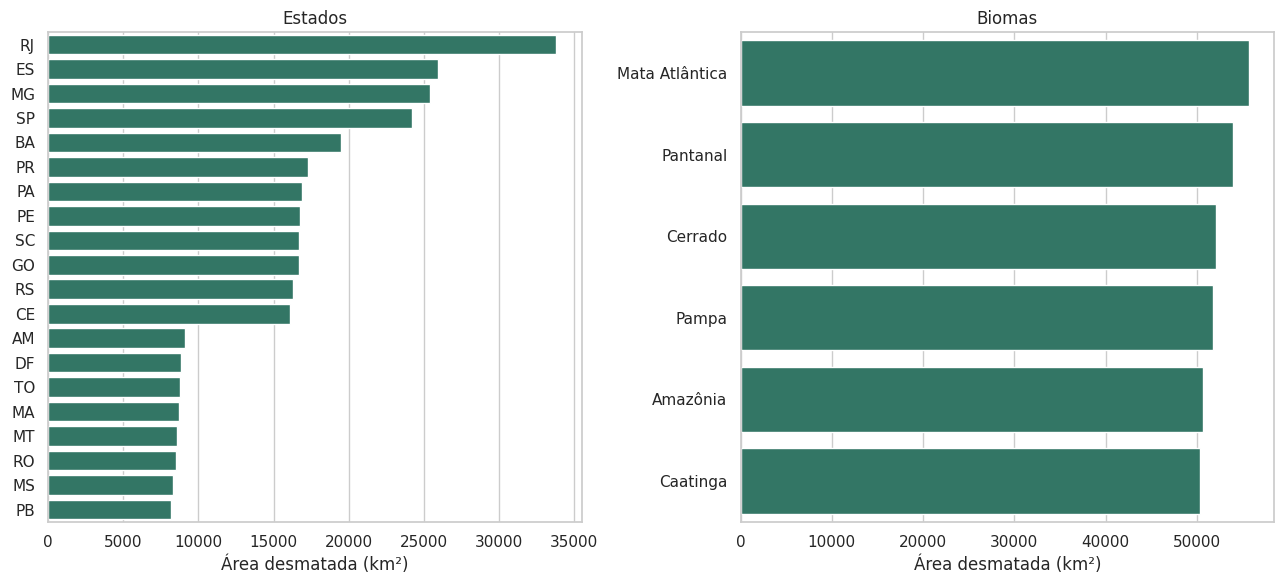

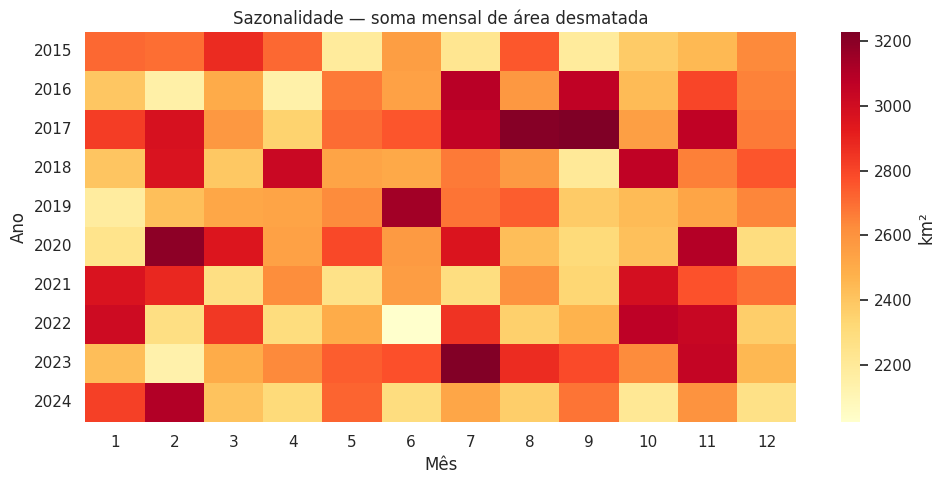

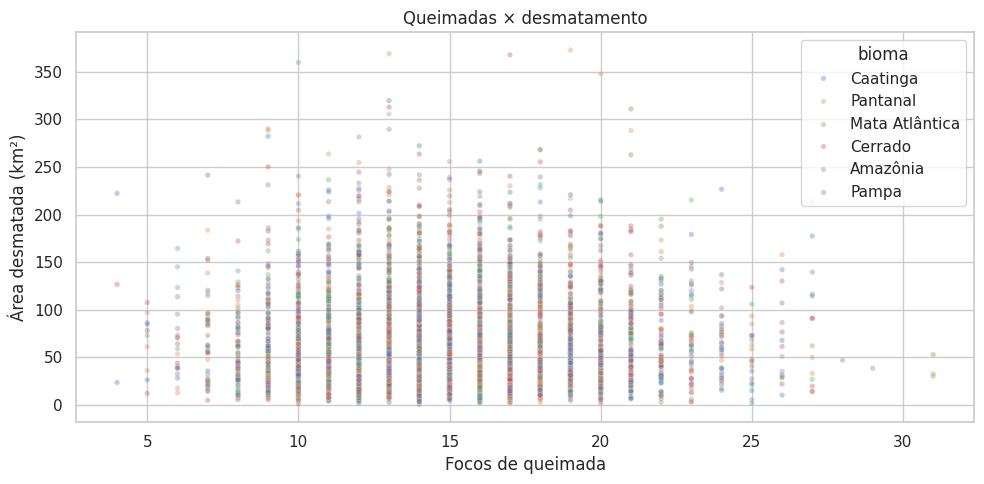

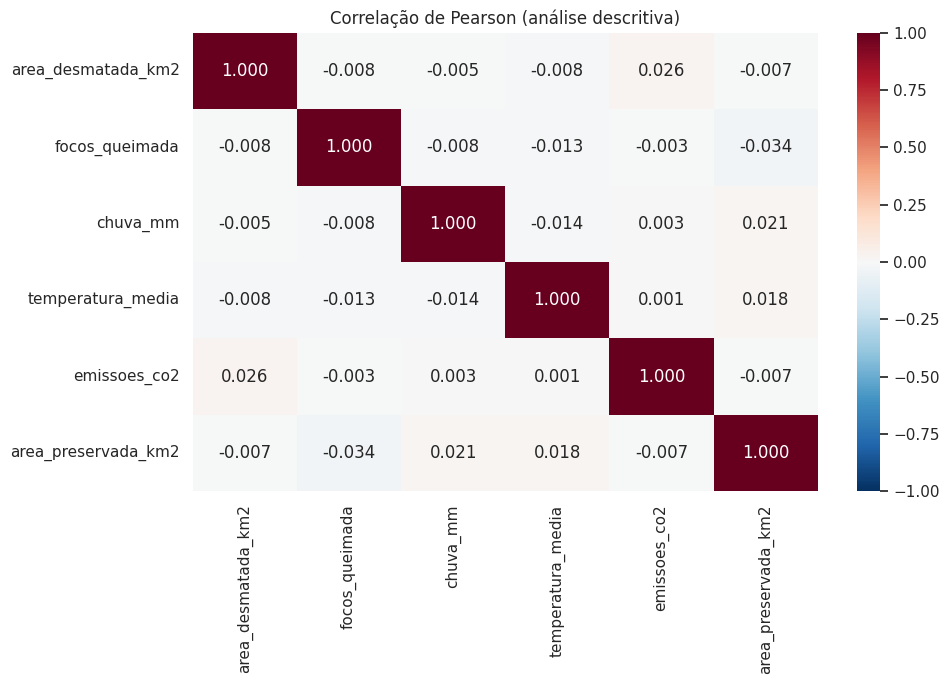

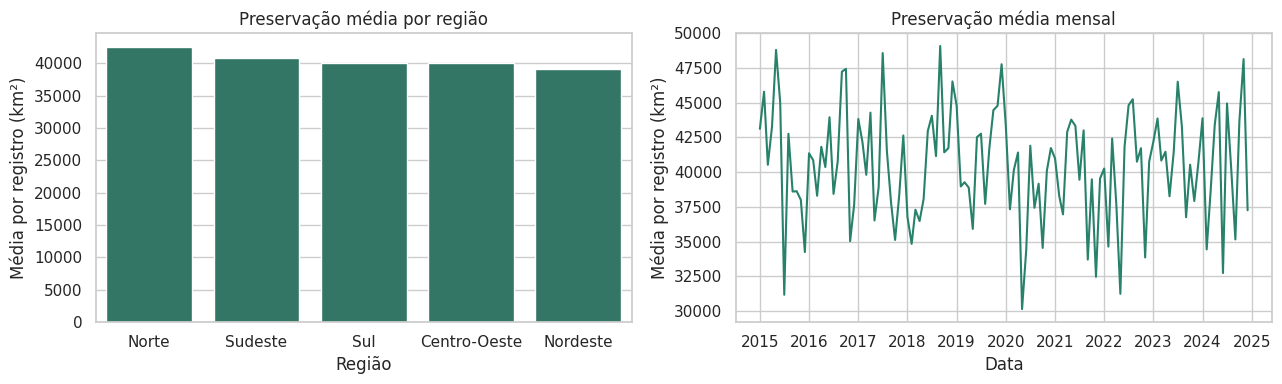

In [6]:
OUT = ROOT / "imagens"
OUT.mkdir(exist_ok=True)
def salvar(fig, nome):
    fig.tight_layout()
    fig.savefig(OUT / nome, dpi=160, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(10,4))
sns.lineplot(data=anual.reset_index(), x="ano", y="area_desmatada_km2", marker="o", ax=ax)
ax.set(title="Evolução anual do desmatamento simulado", xlabel="Ano", ylabel="Área desmatada (km²)")
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
salvar(fig, "evolucao_anual.png")

fig, axes = plt.subplots(1,2,figsize=(13,6))
for ax, col, titulo in [(axes[0], "uf", "Estados"), (axes[1], "bioma", "Biomas")]:
    r = ranking(df, col)
    sns.barplot(x=r.values, y=r.index, ax=ax, color="#28816a")
    ax.set(title=titulo, xlabel="Área desmatada (km²)", ylabel="")
salvar(fig, "comparacoes.png")

fig, ax = plt.subplots(figsize=(10,5))
matriz = df.pivot_table(index="ano", columns="mes", values="area_desmatada_km2", aggfunc="sum")
sns.heatmap(matriz, cmap="YlOrRd", ax=ax, cbar_kws={"label":"km²"})
ax.set(title="Sazonalidade — soma mensal de área desmatada", xlabel="Mês", ylabel="Ano")
salvar(fig, "heatmap_mensal.png")

fig, ax = plt.subplots(figsize=(10,5))
sns.scatterplot(data=df, x="focos_queimada", y="area_desmatada_km2", hue="bioma", alpha=.35, s=15, ax=ax)
ax.set(title="Queimadas × desmatamento", xlabel="Focos de queimada", ylabel="Área desmatada (km²)")
salvar(fig, "dispersao.png")

cols=["area_desmatada_km2","focos_queimada","chuva_mm","temperatura_media","emissoes_co2","area_preservada_km2"]
corr=df[cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".3f", vmin=-1, vmax=1, cmap="RdBu_r", ax=ax)
ax.set(title="Correlação de Pearson (análise descritiva)")
salvar(fig, "correlacao.png")

fig, axes=plt.subplots(1,2,figsize=(13,4))
regioes=df.groupby("regiao").area_preservada_km2.mean().sort_values(ascending=False)
sns.barplot(x=regioes.index,y=regioes.values,ax=axes[0],color="#28816a")
axes[0].set(title="Preservação média por região",xlabel="Região",ylabel="Média por registro (km²)")
mensal=df.groupby("data").area_preservada_km2.mean()
axes[1].plot(mensal.index,mensal.values,color="#28816a")
axes[1].set(title="Preservação média mensal",xlabel="Data",ylabel="Média por registro (km²)")
salvar(fig, "preservacao.png")

## 9. Interpretação dos resultados
Respostas calculadas diretamente da base completa, não de suposições sobre os dados reais do país.

In [7]:
r_uf=ranking(df,"uf");r_bioma=ranking(df,"bioma")
pico_ano=anual.area_desmatada_km2.idxmax()
mensal_desmatada=df.groupby("data").area_desmatada_km2.sum()
pico_mes=mensal_desmatada.idxmax()
variacao=(anual.area_desmatada_km2.iloc[-1]/anual.area_desmatada_km2.iloc[0]-1)*100
r=corr.loc["focos_queimada","area_desmatada_km2"]
preservacao=df.groupby("regiao").area_preservada_km2.mean().sort_values(ascending=False)
print(f"Estado líder: {r_uf.index[0]}, {numero(r_uf.iloc[0])} km². Bioma líder: {r_bioma.index[0]}, {numero(r_bioma.iloc[0])} km².")
print(f"Ano de maior soma: {pico_ano}. Mês de maior soma: {pico_mes:%m/%Y} ({numero(mensal_desmatada.max())} km²).")
print(f"Variação 2015–2024: {numero(variacao)}%. Não há crescimento sustentado, mas oscilações anuais.")
print(f"Pearson queimadas × desmatamento: {r:.4f}. Associação linear muito fraca nessa simulação; não implica causalidade.")
print(f"Maior preservação média por registro: {preservacao.index[0]} ({numero(preservacao.iloc[0])} km²).")
display(df[df.risco_elevado].groupby(["uf","bioma"]).area_desmatada_km2.sum().nlargest(10).to_frame("Área desmatada — risco alto/crítico"))
print("Variação da preservação média de 2015 para 2024 (%):", numero((df[df.ano==2024].area_preservada_km2.mean()/df[df.ano==2015].area_preservada_km2.mean()-1)*100))

Estado líder: RJ, 33.813,80 km². Bioma líder: Mata Atlântica, 55.680,27 km².
Ano de maior soma: 2017. Mês de maior soma: 09/2017 (3.227,13 km²).
Variação 2015–2024: -0,21%. Não há crescimento sustentado, mas oscilações anuais.
Pearson queimadas × desmatamento: -0.0076. Associação linear muito fraca nessa simulação; não implica causalidade.
Maior preservação média por registro: Norte (42.550,00 km²).


Área desmatada — risco alto/crítico
uf bioma                                              
RJ Mata Atlântica                              3688.07
   Pantanal                                    3161.92
MG Pantanal                                    3106.17
RJ Amazônia                                    2823.43
MG Cerrado                                     2813.15
ES Pantanal                                    2501.47
SC Amazônia                                    2490.80
ES Mata Atlântica                              2421.02
RJ Caatinga                                    2377.37
SP Pampa                                       2331.06

Variação da preservação média de 2015 para 2024 (%): -0,33


## 10. Conclusão
A simulação mostra maior soma desmatada em RJ e no bioma Mata Atlântica. O pico anual ocorre em 2017. Entre 2015 e 2024 há leve redução da soma anual, com oscilações intermediárias, e não um crescimento contínuo. O coeficiente de Pearson entre queimadas e desmatamento é aproximadamente −0,0076: não há associação linear relevante na base completa.

O dashboard permite investigar recortes, que podem produzir resultados diferentes do total. Comparar grupos exige considerar quantidades de registros e exposição territorial. Para monitoramento real, seria necessário obter dados oficiais, documentação da amostragem, áreas únicas de preservação, identificação de unidades de conservação e unidade das emissões.

**Conclusão executiva:** usar rankings, picos temporais e categorias de risco como pontos de investigação da simulação, evitando afirmar causalidade ou extrapolar resultados ao Brasil real. As funcionalidades avançadas implementadas são correlação estatística com Pandas/NumPy e dashboard multipágina com Streamlit.